## Explainable AI

## Lime 

### Lime for text data

In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.pipeline import make_pipeline
from lime.lime_text import LimeTextExplainer
from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction.text import TfidfVectorizer
from collections import OrderedDict

In [3]:
# Load training Data
train_df = pd.read_csv(r"M:\Learning 2026\ai-engineering-refresh\ExplainableAI\train.csv\train.csv")
print("Train shape :", train_df.shape)
train_df.head()

Train shape : (1306122, 3)


,qid,question_text,target
0,00002165364db923c7e6,How did Quebec nationalists see their province...,0
1,000032939017120e6e44,"Do you have an adopted dog, how would you enco...",0
2,0000412ca6e4628ce2cf,Why does velocity affect time? Does velocity a...,0
3,000042bf85aa498cd78e,How did Otto von Guericke used the Magdeburg h...,0
4,0000455dfa3e01eae3af,Can I convert montra helicon D to a mountain b...,0


In [9]:
new_rows = train_df[train_df.isna().any(axis=1)]
print("Number of rows with missing values:", len(new_rows))


Number of rows with missing values: 0


In [12]:
#split the data imto training and validation sets
X_train, X_val, y_train, y_val = train_test_split(train_df["question_text"], train_df["target"], test_size=0.2, random_state=42)

In [13]:
X_train.shape, y_train.shape, X_val.shape, y_val.shape


((1044897,), (1044897,), (261225,), (261225,))

In [18]:
print(X_train.head())

298773     How is strategic positioning is different from...
815475     What is the best way for promote Facebook mark...
1133453    How much energized proton radiation does the I...
1076426    Would any Indian men want to marry a women tha...
203792     Which is the best business for startups in Ind...
Name: question_text, dtype: object


In [20]:
tfidf_vc = TfidfVectorizer(min_df =10 , max_features = 10000, analyzer="word", ngram_range=(1,2),stop_words="english")
train_vc = tfidf_vc.fit_transform(X_train)
val_vc = tfidf_vc.transform(X_val)

In [21]:
model = LogisticRegression()
model.fit(train_vc, y_train)

val_pred = model.predict(val_vc)

In [23]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, recall_score, precision_score, f1_score
print("Accuracy:", accuracy_score(y_val, val_pred))
print("Recall:", recall_score(y_val, val_pred))
print("Precision:", precision_score(y_val, val_pred))
print("F1 Score:", f1_score(y_val, val_pred))

Accuracy: 0.9517312661498708
Recall: 0.3815590312815338
Precision: 0.683384163560375
F1 Score: 0.4897001092719252


In [24]:
print("Confusion Matrix:\n", confusion_matrix(y_val, val_pred))


Confusion Matrix:
 [[242566   2803]
 [  9806   6050]]


In [25]:
class_names = ['sincere', 'insincere']
class_report = classification_report(y_val, val_pred, target_names=class_names)
print("Classification Report:\n", class_report)

Classification Report:
               precision    recall  f1-score   support

     sincere       0.96      0.99      0.97    245369
   insincere       0.68      0.38      0.49     15856

    accuracy                           0.95    261225
   macro avg       0.82      0.69      0.73    261225
weighted avg       0.94      0.95      0.95    261225



In [41]:
target_1_rows = train_df[train_df["target"] == 1]
target_0_rows = train_df[train_df["target"] == 0]
print("Number of sincere questions:", len(target_0_rows))
print("Number of insincere questions :", len(target_1_rows))


Number of sincere questions: 1225312
Number of insincere questions : 80810


In [42]:
print(target_1_rows)

                          qid  \
22       0000e91571b60c2fb487   
30       00013ceca3f624b09f42   
110      0004a7fcb2bf73076489   
114      00052793eaa287aff1e1   
115      000537213b01fd77b58a   
...                       ...   
1306093  fffeba722d9b371bd1b9   
1306094  fffee269360dd0d3947a   
1306099  ffff0e4ea1bb6e16feec   
1306103  ffff3f0a2449ffe4b9ff   
1306112  ffffa5b0fa76431c063f   

                                             question_text  target  
22       Has the United States become the largest dicta...       1  
30       Which babies are more sweeter to their parents...       1  
110      If blacks support school choice and mandatory ...       1  
114      I am gay boy and I love my cousin (boy). He is...       1  
115                   Which races have the smallest penis?       1  
...                                                    ...     ...  
1306093  How is it to have intimate relation with your ...       1  
1306094  Why is it when singers have lyrics about v

In [45]:
print("Row indices of rows with target = 1:")
print( target_1_rows.index.tolist())

Row indices of rows with target = 1:
[22, 30, 110, 114, 115, 119, 127, 144, 156, 167, 168, 208, 214, 224, 235, 260, 286, 289, 291, 302, 315, 333, 362, 397, 400, 439, 460, 496, 538, 544, 553, 569, 571, 615, 617, 627, 725, 742, 765, 798, 803, 822, 841, 855, 869, 970, 996, 999, 1012, 1014, 1021, 1039, 1057, 1062, 1080, 1085, 1101, 1107, 1116, 1129, 1149, 1168, 1169, 1183, 1206, 1234, 1237, 1243, 1265, 1281, 1303, 1314, 1325, 1331, 1338, 1340, 1346, 1379, 1389, 1393, 1413, 1424, 1439, 1448, 1453, 1496, 1501, 1514, 1532, 1572, 1583, 1590, 1620, 1625, 1631, 1636, 1651, 1671, 1678, 1680, 1696, 1704, 1712, 1717, 1719, 1727, 1739, 1742, 1743, 1778, 1789, 1804, 1824, 1835, 1837, 1867, 1868, 1872, 1874, 1878, 1937, 1955, 1972, 1987, 1992, 2011, 2012, 2021, 2024, 2059, 2063, 2074, 2099, 2100, 2153, 2159, 2169, 2177, 2190, 2206, 2215, 2223, 2270, 2289, 2294, 2351, 2356, 2363, 2371, 2398, 2400, 2438, 2443, 2447, 2457, 2470, 2474, 2492, 2495, 2498, 2508, 2529, 2534, 2555, 2600, 2604, 2617, 2622, 2646

In [66]:
#Create a LIMe text explainer 
explainer = LimeTextExplainer(class_names=class_names)
prediction_index = 12
idx = int(X_val.index[prediction_index])
text = X_val.loc[idx]
c = make_pipeline(tfidf_vc, model)

exp = explainer.explain_instance(text, c.predict_proba, num_features=10)

print(text)
print("Probability(sincere) = ", c.predict_proba([text])[0][0])
print("Probability(insincere) = ", c.predict_proba([text])[0][1])
print("True class: %s" % class_names[int(y_val.loc[idx])])



What are the ways to earn money using your brand new car except attaching it to Uber/Ola?
Probability(sincere) =  0.9967325891288993
Probability(insincere) =  0.003267410871100692
True class: sincere


In [67]:
exp.as_list()

[('brand', -0.0019172073016571933),
 ('ways', -0.0017057061496353239),
 ('money', 0.001666303493752234),
 ('earn', -0.0013056362657845374),
 ('car', -0.0010602057070154697),
 ('Ola', -0.0010351149632771093),
 ('using', 0.0008590672675697304),
 ('Uber', -0.0006867326880945256),
 ('new', 0.00038510738859670607),
 ('except', 8.243195655943317e-05)]

In [68]:
exp.show_in_notebook(text=True)

In [72]:
print('Original Prediction:', model.predict_proba(val_vc[prediction_index])[0,1])

tmp = val_vc[prediction_index].copy()
tmp[0, tfidf_vc.vocabulary_['brand']] = 0
print('Prediction after removing "brand":', model.predict_proba(tmp)[0,1])

print('Difference in prediction:', model.predict_proba(val_vc[prediction_index])[0,1] - model.predict_proba(tmp)[0,1])


Original Prediction: 0.003267410871100692
Prediction after removing "brand": 0.004416402795470181
Difference in prediction: -0.0011489919243694888


In [73]:
exp.show_in_notebook(text=X_val["question_text"][idx], show_table=True)

KeyError: 'question_text'

## Lime for Image data

In [74]:
import os
import keras
from keras.applications import inception_v3 as inception
from keras.preprocessing import image
from keras.applications.imagenet_utils import decode_predictions
from skimage.io import imread
import matplotlib.pyplot as plt
%matplotlib inline
import numpy as np
print("Keras version:", keras.__version__)

Keras version: 3.11.2


In [75]:
inet_model = inception.InceptionV3()

96112376/96112376 ━━━━━━━━━━━━━━━━━━━━ 169s 2us/step


In [85]:
def preprocess_image(path_list):
    out = []
    for img_path in path_list:
        img = image.load_img(img_path, target_size=(299, 299))
        x = image.img_to_array(img)
        x = np.expand_dims(x, axis=0)
        x = inception.preprocess_input(x)
        out.append(x)
    return np.vstack(out)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 342ms/step
Predicted: [('n03598930', 'jigsaw_puzzle', 0.049688622), ('n02504013', 'Indian_elephant', 0.023093257), ('n02129165', 'lion', 0.023003431)]


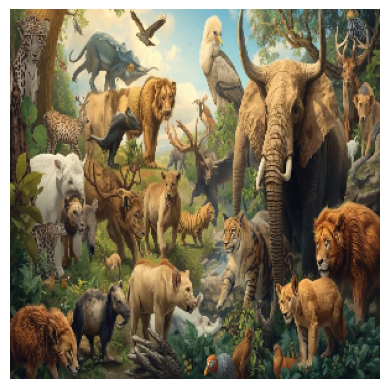

jigsaw_puzzle: 4.97%
Indian_elephant: 2.31%
lion: 2.30%
toyshop: 2.26%
Saint_Bernard: 1.58%


In [95]:
images = preprocess_image([os.path.join(r"M:\Learning 2026\ai-engineering-refresh\ExplainableAI\data", "image.png")])
plt.imshow(images[0] / 2 + 0.5)
preds = inet_model.predict(images)
print('Predicted:', decode_predictions(preds, top=3)[0])
plt.axis('off')
plt.show()
for x in decode_predictions(preds)[0]:
    print("%s: %.2f%%" % (x[1], x[2]*100))


In [92]:
from lime import lime_image
explainer = lime_image.LimeImageExplainer()
explanation = explainer.explain_instance(images[0].astype('double'), inet_model.predict, top_labels=5, hide_color=0, num_samples=1000)

  0%|          | 0/1000 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 983ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 984ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step   
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 996ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━

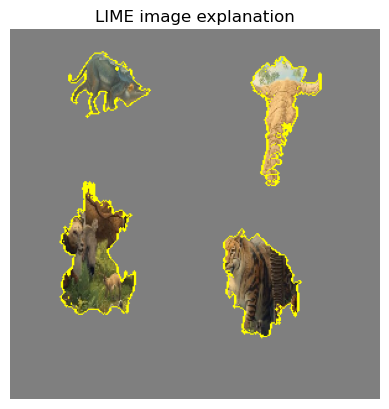

In [108]:
from skimage.segmentation import mark_boundaries
temp, mask = explanation.get_image_and_mask(explanation.top_labels[0], positive_only=True, num_features=5, hide_rest=True)
plt.imshow(mark_boundaries(temp / 2 + 0.5, mask))
plt.axis('off')
plt.title("LIME image explanation")
plt.show()


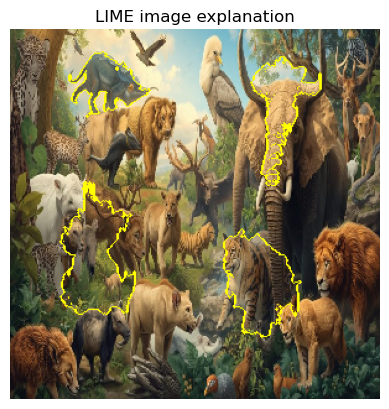

In [109]:
temp, mask = explanation.get_image_and_mask(explanation.top_labels[0], positive_only=True, num_features=5, hide_rest=False)
plt.imshow(mark_boundaries(temp / 2 + 0.5, mask))
plt.axis('off')
plt.title("LIME image explanation")
plt.show()


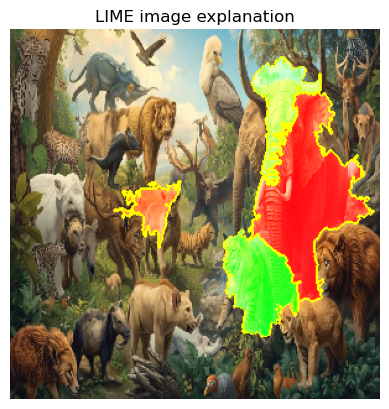

In [113]:
temp, mask = explanation.get_image_and_mask(explanation.top_labels[0], positive_only=False, num_features=5, hide_rest=False, min_weight=0.01)
plt.imshow(mark_boundaries(temp / 2 + 0.5, mask))
plt.axis('off')
plt.title("LIME image explanation")
plt.show()


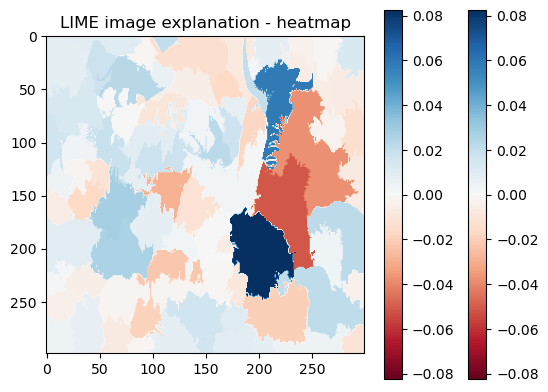

In [118]:
ind = explanation.top_labels[0]
dict_heatmap = dict(explanation.local_exp[ind])
heatmap = np.vectorize(dict_heatmap.get)(explanation.segments)
plt.imshow(heatmap, cmap='RdBu', vmin=-max(dict_heatmap.values()), vmax=max(dict_heatmap.values()))
plt.colorbar()
plt.title("LIME image explanation - heatmap")
plt.show()

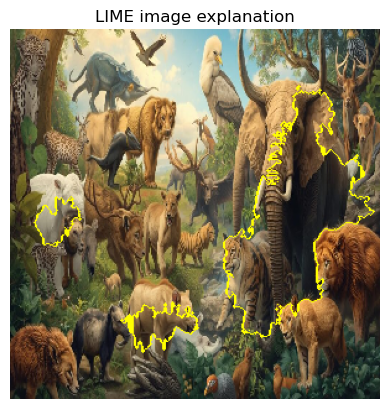

In [125]:
temp, mask = explanation.get_image_and_mask(explanation.top_labels[3], positive_only=True, num_features=5, hide_rest=False)
plt.imshow(mark_boundaries(temp / 2 + 0.5, mask))
plt.axis('off')
plt.title("LIME image explanation")
plt.show()


### Lime on Tabular data

In [128]:
import sklearn
import sklearn.datasets
from sklearn.ensemble import RandomForestClassifier
import numpy as np
import lime
from lime import lime_tabular
from __future__ import print_function

# set seed for reproducibility
np.random.seed(1)

In [129]:
import pandas as pd
from sklearn.datasets import load_iris

iris = load_iris()
df = pd.DataFrame(data=iris.data, columns=iris.feature_names)
df['target']= iris.target
print(df.head())

   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   target  
0       0  
1       0  
2       0  
3       0  
4       0  


In [130]:
X_train, X_val, y_train, y_val = train_test_split(df[iris.feature_names], df['target'], test_size=0.2, random_state=42)
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [132]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
print("Accuracy:", accuracy_score(y_val, rf.predict(X_val)))
print("Classification Report:\n", classification_report(y_val, rf.predict(X_val)))
print("Confusion Matrix:\n", confusion_matrix(y_val, rf.predict(X_val)))


Accuracy: 1.0
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30

Confusion Matrix:
 [[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

# Quick automated checks for the notebook reports

issues = []

# Missing values
try:
    mv_total = missing_values.sum().sum() if hasattr(missing_values, 'sum') else int(missing_values.sum())
    print(f"Missing values total: {mv_total}")
    if mv_total > 0:
        issues.append("missing_values")
except NameError:
    print("missing_values not defined")

# Class balance
try:
    n_total = len(train_df)
    n_pos = len(target_1_rows)
    ratio = n_pos / n_total
    print(f"Positive class ratio: {ratio:.3f} ({n_pos}/{n_total})")
    if ratio < 0.05:
        issues.append("severe_class_imbalance")
    elif ratio < 0.2:
        issues.append("moderate_class_imbalance")
except NameError:
    print("train_df or target_1_rows not defined")

# Model performance
try:
    acc = accuracy_score(y_val, val_pred)
    prec = precision_score(y_val, val_pred, zero_division=0)
    rec = recall_score(y_val, val_pred, zero_division=0)
    f1 = f1_score(y_val, val_pred, zero_division=0)
    print(f"Accuracy: {acc:.3f}, Precision: {prec:.3f}, Recall: {rec:.3f}, F1: {f1:.3f}")
    if f1 < 0.5 or (prec < 0.5 and rec < 0.5):
        issues.append("poor_model_performance")
    elif f1 < 0.7:
        issues.append("ok_but_can_improve")
except Exception as e:
    print("Could not compute model metrics:", e)

# Confusion matrix sanity
try:
    cm = confusion_matrix(y_val, val_pred)
    print("Confusion matrix:\n", cm)
except Exception:
    pass

# LIME presence
if 'exp' in globals():
    print("Text LIME explainer (exp) present")
else:
    issues.append("no_text_lime")
if 'explanation' in globals():
    print("Image LIME explanation present")
else:
    issues.append("no_image_lime")

# Final verdict
if issues:
    print("\nVerdict: Some reports need review:", issues)
else:
    print("\nVerdict: All reports look good")